![](Images/banner_health_analytics.png){fig-align="center" width="100%"}


### Module 07: Geospatial & Spatial Epidemiology


# Capstone · Spatial Health Inequity Atlas



**This capstone integrates NB-01 through NB-07 into a comprehensive spatial health inequity analysis using real US county data.**

**Data:** `Data/usa_data.csv` — CDC adult diabetes prevalence and County Health Rankings covariates for 3,108 counties (CONUS + DC)  
**Geometries:** `Data/US_COUNTY.shp` — county polygons in NAD83 Albers (EPSG:5070)

**Research Question:** Where are counties with high adult diabetes prevalence, high obesity, AND a poor food environment / weak primary-care access simultaneously concentrated — and how does this geographic intersection relate to age structure and uninsurance?

**Pipeline stages:**
1. Data assembly: join CHR/CDC attributes to county polygons
2. Spatial autocorrelation: Moran's I + LISA for diabetes, obesity, and food environment
3. Spatial cluster detection: Kulldorff scan statistic for diabetes hot spots
4. Spatial regression: OLS → spatial lag model (diabetes on obesity, age 65+, exercise access, food environment)
5. Empirical Bayes disease mapping: Gamma-Poisson smoothed SMR surface
6. Access mapping: 2SFCA using PCP supply and uninsured demand
7. Compound disadvantage index: counties carrying multiple simultaneous burdens
8. Publication-quality 8-panel figure (300 dpi) + methods narrative

**Estimated time:** 4 hours | **Level:** Advanced


## 0. Setup & County Dataset

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec, matplotlib.colors as mcolors
import matplotlib.cm as cm, seaborn as sns
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
from scipy import stats
import statsmodels.api as sm
from pyproj import Transformer
import warnings; warnings.filterwarnings("ignore")
import os; os.makedirs("/tmp/mod07", exist_ok=True)
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":300,"figure.facecolor":"white",
                     "axes.spines.top":False,"axes.spines.right":False})

# County Health Rankings + CDC diabetes prevalence (CONUS + DC)
raw = pd.read_csv("Data/usa_data.csv")

# Centroids stored as NAD83 Albers metres (EPSG:5070) — convert to WGS84 lon/lat
to_wgs84 = Transformer.from_crs(5070, 4326, always_xy=True)
lon, lat = to_wgs84.transform(raw.centroid_x_m.values, raw.centroid_y_m.values)

df = pd.DataFrame({
    "county_id": raw.fips.astype(str).str.zfill(5),
    "fips": raw.fips.astype(int),
    "county": raw.county, "state_abbr": raw.state_abbr, "state_name": raw.state_name,
    "lon": lon, "lat": lat,
    "x_m": raw.centroid_x_m, "y_m": raw.centroid_y_m,
    "diabetes_prev": raw.y_diabetes_prevalence_adults_with_diabetes,
    "pct_65plus": raw.chr_65_and_older_65_and_over,
    "pct_exercise": raw.chr_access_to_exercise_opportunities,
    "pct_obesity": raw.chr_adult_obesity,
    "food_env_index": raw.chr_food_environment_index,
    "n_pcp": raw.chr_primary_care_physicians,
    "rural_pop": raw.chr_rural,
    "n_unemployed": raw.chr_unemployment,
    "n_uninsured": raw.chr_uninsured,
})

# Standardised prevalence ratio: county rate / national mean (SMR analogue)
df["smr"] = df.diabetes_prev / df.diabetes_prev.replace(0, np.nan).mean()
df.rename(columns={"diabetes_prev": "Diabetes"}, inplace=True)
df.rename(columns={"pct_obesity": "Obesity"}, inplace=True)
df.rename(columns={"pct_65plus": "Population 65+"}, inplace=True)
df.rename(columns={"food_env_index": "Food env. index"}, inplace=True)
df.rename(columns={"n_pcp": "PCP"}, inplace=True)
df.rename(columns={"n_unemployed": "Unemployed"}, inplace=True)
df.rename(columns={"n_uninsured": "Uninsured"}, inplace=True)

N_COUNTIES = len(df)
print(f"County dataset: N={N_COUNTIES} | Diabetes: {df['Diabetes'].mean():.1f}% (SD={df['Diabetes'].std():.1f})")
print(f"Obesity: {df['Obesity'].mean():.1f}% | 65+: {df['Population 65+'].mean():.1f}% | Food env. index: {df['Food env. index'].mean():.1f}")

# Join df with Data/US_COUNTY.shp to create a spatial GeoDataFrame
try:
    import geopandas as gpd
    from shapely.geometry import Point
    print(f"geopandas {gpd.__version__} available")
    GEOPANDAS_OK = True
except ImportError:
    print("geopandas or shapely not found. Please install with: pip install geopandas shapely")
    GEOPANDAS_OK = False

if GEOPANDAS_OK:
    county_shapes = gpd.read_file("Data/US_COUNTY.shp")
    county_shapes["FIPS"] = county_shapes["FIPS"].astype(int)
    # Update Shannon County SD (46113) to Oglala Lakota (46102)
    county_shapes["FIPS"] = county_shapes["FIPS"].replace({46113: 46102})
    gdf = county_shapes.merge(df, left_on="FIPS", right_on="fips", how="inner")
    # Keep tabular df in the same row order as gdf (required for W · y alignment)
    df = gdf.drop(columns="geometry").copy()
    N = N_COUNTIES = len(gdf)
    print(f"GeoDataFrame loaded: {len(gdf)} counties")
    print(f"CRS: {gdf.crs}")
    print(f"Bounding box (Albers meters): {np.round(gdf.total_bounds, 0)}")
else:
    N = N_COUNTIES
    print("geopandas not available; spatial DataFrame could not be created.")


County dataset: N=3108 | Diabetes: 10.5% (SD=2.2)
Obesity: 36.2% | 65+: 20.1% | Food env. index: 7.4
geopandas 1.1.2 available


GeoDataFrame loaded: 3108 counties
CRS: PROJCS["NAD_1983_Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Bounding box (Albers meters): [-2356114.   268091.  2258200.  3172568.]


## 1. Build Spatial Weights

In [2]:
from libpysal.weights import Queen

# Queen contiguity from county polygons (not a synthetic grid)
w_queen = Queen.from_dataframe(gdf, use_index=True, silence_warnings=True)
W = w_queen.full()[0].astype(float)
rs = W.sum(axis=1, keepdims=True); rs[rs == 0] = 1
W = W / rs
W_bin = (W > 0).astype(float)
N = len(gdf)

print(f"Spatial weights: Queen contiguity | N={N}×{N}")
print(f"Mean neighbours: {(W > 0).sum(axis=1).mean():.1f} | Isolates: {int((W_bin.sum(axis=1) == 0).sum())}")


Spatial weights: Queen contiguity | N=3108×3108
Mean neighbours: 5.8 | Isolates: 2


## 2. Global & Local Moran's I

In [3]:
def morans_i(y, W, n_perm=499, seed=42):
    n = len(y); z = y - y.mean(); S0 = W.sum()
    I = (n / S0) * (z @ (W @ z)) / (z @ z)
    rng = np.random.default_rng(seed)
    Ip = np.array([(n / S0) * (rng.permutation(z) @ (W @ rng.permutation(z))) / (z @ z)
                   for _ in range(n_perm)])
    p = (np.abs(Ip) >= abs(I)).mean()
    return I, p

def local_morans(y, W, n_perm=199, seed=42):
    n = len(y); z = y - y.mean(); vz = z.var()
    Wz = W @ z; Il = z * Wz / vz
    rng = np.random.default_rng(seed)
    Ip = np.array([(rng.permutation(z) * (W @ rng.permutation(z)) / vz) for _ in range(n_perm)])
    pv = (np.abs(Ip) >= np.abs(Il)).mean(axis=0)
    zstd = z / z.std(); zlag = Wz / z.std()
    quad = np.where((zstd > 0) & (zlag > 0), "HH",
           np.where((zstd < 0) & (zlag < 0), "LL", "Other"))
    return np.where(pv < 0.05, quad, "NS"), Il, pv

I_diab, p_diab = morans_i(gdf["Diabetes"].values, W)
I_ob,   p_ob   = morans_i(gdf["Obesity"].values, W)
I_fe,   p_fe   = morans_i(gdf["Food env. index"].values, W)
print("Global Moran's I:")
print(f"  Diabetes         : {I_diab:.4f} (p={p_diab:.4f})")
print(f"  Obesity          : {I_ob:.4f} (p={p_ob:.4f})")
print(f"  Food env. index  : {I_fe:.4f} (p={p_fe:.4f})")

lisa_diab, _, p_lisa = local_morans(gdf["Diabetes"].values, W)
gdf["lisa_diabetes"] = lisa_diab
gdf["lisa_p_diabetes"] = p_lisa
df["lisa_diabetes"] = lisa_diab
print(f"\nLISA Diabetes: HH={(lisa_diab=='HH').sum()}  LL={(lisa_diab=='LL').sum()}  "
      f"Other={(lisa_diab=='Other').sum()}  NS={(lisa_diab=='NS').sum()}")


Global Moran's I:
  Diabetes         : 0.6650 (p=0.0000)
  Obesity          : 0.6255 (p=0.0000)
  Food env. index  : 0.3389 (p=0.0000)



LISA Diabetes: HH=413  LL=341  Other=12  NS=2342


## 3. Spatial Cluster Detection (Scan Statistic)

In [4]:
# Poisson scan on diabetes: this extract has no total population, so Uninsured
# (a CHR count that scales with county size) is the working at-risk denominator.
# Observed = prevalence × n; expected is n-weighted national mean (O/E = SPR).
rng = np.random.default_rng(11)
n_atrisk = gdf["Uninsured"].clip(lower=1).to_numpy(float)
prev = gdf["Diabetes"].to_numpy(float) / 100
o = prev * n_atrisk
e = n_atrisk * (o.sum() / n_atrisk.sum())
e *= o.sum() / e.sum()
Otot, Etot = o.sum(), e.sum()
gdf["observed"] = o
gdf["expected"] = e
df["observed"] = o
df["expected"] = e

xy = np.column_stack([gdf.geometry.centroid.x.values, gdf.geometry.centroid.y.values])
MAXWIN = 500   # ~15% of counties — keeps the primary cluster interpretable
_, NB = cKDTree(xy).query(xy, k=MAXWIN)

def scan(ovec, arg=False):
    Oz = np.cumsum(ovec[NB], axis=1)
    Ez = np.cumsum(e[NB], axis=1)
    Oout = Otot - Oz; Eout = Etot - Ez
    with np.errstate(divide="ignore", invalid="ignore"):
        llr = np.where(Oz > 0, Oz * np.log(Oz / Ez), 0.) + \
              np.where(Oout > 0, Oout * np.log(Oout / Eout), 0.)
    llr = np.where(((Oz / Ez) > (Oout / Eout)) & (Ez <= 0.15 * Etot) & np.isfinite(llr),
                   llr, -np.inf)
    if arg:
        f = np.argmax(llr)
        return llr.flat[f], divmod(f, MAXWIN)
    return llr.max()

print("Running scan statistic...")
best_llr, (best_c, ck) = scan(o, arg=True)
best_in = NB[best_c, :ck + 1]
Oc, Ec = o[best_in].sum(), e[best_in].sum()
RR = (Oc / Ec) / ((Otot - Oc) / (Etot - Ec))

n_perm = 99
mc = np.array([scan(rng.multinomial(int(Otot), e / Etot).astype(float)) for _ in range(n_perm)])
p_scan = (np.sum(mc >= best_llr) + 1) / (n_perm + 1)

gdf["in_scan_cluster"] = False
gdf.iloc[best_in, gdf.columns.get_loc("in_scan_cluster")] = True
df["in_scan_cluster"] = gdf["in_scan_cluster"].values
cx, cy = xy[best_c]
best_r = np.sqrt(((xy[best_in] - xy[best_c]) ** 2).sum(1).max())

print(f"Primary cluster: LLR={best_llr:.1f}  p={p_scan:.3f}  n={len(best_in)} counties  RR={RR:.2f}")
print("Top states:", gdf.iloc[best_in].state_abbr.value_counts().head(6).to_dict())


Running scan statistic...


Primary cluster: LLR=5410.5  p=0.010  n=32 counties  RR=1.52
Top states: {'TX': 32}


## 4. Spatial Regression

In [5]:
# Diabetes ~ obesity + age 65+ + exercise access + food environment
COVARIATES = ["Obesity", "Population 65+", "pct_exercise", "Food env. index"]
X = sm.add_constant(gdf[COVARIATES])
y = gdf["Diabetes"]
ols = sm.OLS(y, X).fit()
ols_ob = ols.params["Obesity"]
I_resid, p_resid = morans_i(ols.resid.values, W, n_perm=299)
print("OLS:")
print(ols.summary().tables[1])
print(f"R²={ols.rsquared:.3f} | AIC={ols.aic:.1f} | Moran I(resid)={I_resid:.4f} (p={p_resid:.4f})")

# Spatial lag via concentrated likelihood; log-det from eigenvalues of W (once)
print("\nFitting spatial lag model (eigenvalue log-det)...")
evals = np.linalg.eigvals(W).real
y_arr = y.values; X_arr = X.values; n = N
Wy = W @ y_arr
rho_grid = np.linspace(-0.95, 0.95, 39)
ll_grid = []
for rho in rho_grid:
    Ay = y_arr - rho * Wy
    b = np.linalg.lstsq(X_arr, Ay, rcond=None)[0]
    e_hat = Ay - X_arr @ b
    s2 = (e_hat @ e_hat) / n
    ld = np.log(np.clip(1 - rho * evals, 1e-12, None)).sum()
    ll_grid.append(-n/2 * np.log(2*np.pi) - n/2 * np.log(s2) + ld - n/2)
rho_best = rho_grid[np.argmax(ll_grid)]
Ay = y_arr - rho_best * Wy
b_slm = np.linalg.lstsq(X_arr, Ay, rcond=None)[0]
slm_ob = b_slm[list(X.columns).index("Obesity")]
print(f"SLM: rho={rho_best:.3f} | obesity β={slm_ob:.3f} | OLS obesity β={ols_ob:.3f} | "
      f"Δ={slm_ob - ols_ob:+.3f}")


OLS:
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               5.5019      0.337     16.332      0.000       4.841       6.162
Obesity             0.2855      0.006     50.183      0.000       0.274       0.297
Population 65+     -0.0772      0.005    -14.981      0.000      -0.087      -0.067
pct_exercise       -0.0012      0.001     -1.118      0.263      -0.003       0.001
Food env. index    -0.5087      0.019    -27.026      0.000      -0.546      -0.472
R²=0.654 | AIC=10448.6 | Moran I(resid)=0.5366 (p=0.0000)

Fitting spatial lag model (eigenvalue log-det)...


SLM: rho=0.500 | obesity β=0.197 | OLS obesity β=0.285 | Δ=-0.089


## 5. Empirical Bayes Disease Mapping

In [6]:
# Gamma-Poisson EB smoothing of the diabetes SMR (O = prevalence × uninsured n)
smr_mean = (gdf.observed / gdf.expected).mean()
smr_var = (gdf.observed / gdf.expected).var()
extra_var = max(smr_var - smr_mean / gdf.expected.mean(), 0.01)
alpha_hat = smr_mean ** 2 / extra_var
beta_hat = smr_mean / extra_var
gdf["smr_eb"] = (gdf.observed + alpha_hat) / (gdf.expected + beta_hat)
gdf["smr_shrinkage"] = 1 - (gdf.expected / (gdf.expected + beta_hat))
df["smr_eb"] = gdf["smr_eb"].values
print(f"EB hyperparameters: α={alpha_hat:.3f}, β={beta_hat:.3f} (prior mean={alpha_hat/beta_hat:.3f})")
print(f"EB smoothing: raw SMR SD={gdf.smr.std():.4f} → smoothed SD={gdf.smr_eb.std():.4f}")
print(f"Variance reduction: {(1 - gdf.smr_eb.std() / gdf.smr.std()) * 100:.1f}%")
print(f"Mean shrinkage: {gdf.smr_shrinkage.mean()*100:.1f}% | "
      f"high shrinkage (>50%): {(gdf.smr_shrinkage > 0.5).sum()} counties")


EB hyperparameters: α=23.712, β=24.060 (prior mean=0.986)
EB smoothing: raw SMR SD=0.2104 → smoothed SD=0.1604
Variance reduction: 23.8%
Mean shrinkage: 22.6% | high shrinkage (>50%): 339 counties


## 6. Access Metrics & Compound Disadvantage Index

In [7]:
# 2SFCA: PCP supply at county centroids; Uninsured count as need-weighted demand.
# Distances are in Albers metres; 100 km catchment with power-2 decay.
county_coords = np.column_stack([gdf.x_m.values, gdf.y_m.values])
CATCH_M = 100_000
demand = gdf["Uninsured"].clip(lower=1).to_numpy(float)
supply = gdf["PCP"].to_numpy(float)
dist_mat = cdist(county_coords, county_coords)
w_ij = np.where(dist_mat <= CATCH_M, 1.0 / (dist_mat + 1.0) ** 2, 0.0)
denom = w_ij.T @ demand
R_j = np.divide(supply, denom, out=np.zeros_like(supply), where=denom > 0)
A_i = w_ij @ R_j
gdf["access_2sfca"] = A_i
df["access_2sfca"] = A_i
print(f"2SFCA (PCP × uninsured demand, 100 km): mean={A_i.mean():.4g}  SD={A_i.std():.4g}")
print(f"  counties with zero access: {(A_i == 0).sum()}")
print(f"  corr(2SFCA, Diabetes) = {np.corrcoef(A_i, gdf['Diabetes'])[0,1]:+.3f}")

# Compound disadvantage index (quintile scores; all components are rates/indices)
def quintile_score(v, higher_is_worse=True):
    q = pd.qcut(v, 5, labels=[1, 2, 3, 4, 5], duplicates="drop").astype(float)
    return q if higher_is_worse else 6 - q

gdf["cdi"] = (
    quintile_score(gdf["Diabetes"]) +
    quintile_score(gdf["Obesity"]) +
    quintile_score(gdf["Food env. index"], higher_is_worse=False) +
    quintile_score(gdf["pct_exercise"], higher_is_worse=False) +
    quintile_score(gdf["access_2sfca"], higher_is_worse=False)
) / 5
gdf["cdi_cat"] = pd.cut(gdf.cdi, bins=[0, 2, 3, 4, 5.1],
                        labels=["Low", "Moderate", "High", "Very High"])
df["cdi"] = gdf["cdi"].values
df["cdi_cat"] = gdf["cdi_cat"].values

print("\nCompound Disadvantage Index (diabetes + obesity + poor food env. + low exercise + poor PCP access):")
for cat in ["Low", "Moderate", "High", "Very High"]:
    n_c = (gdf.cdi_cat == cat).sum()
    print(f"  {cat:12s}: {n_c:4d} counties ({n_c / N * 100:5.1f}%)")


2SFCA (PCP × uninsured demand, 100 km): mean=0.0145  SD=0.01507
  counties with zero access: 1
  corr(2SFCA, Diabetes) = -0.383



Compound Disadvantage Index (diabetes + obesity + poor food env. + low exercise + poor PCP access):
  Low         :  706 counties ( 22.7%)
  Moderate    :  891 counties ( 28.7%)
  High        :  975 counties ( 31.4%)
  Very High   :  536 counties ( 17.2%)


## 7. Publication Summary Figure (8 panels, 300 dpi)

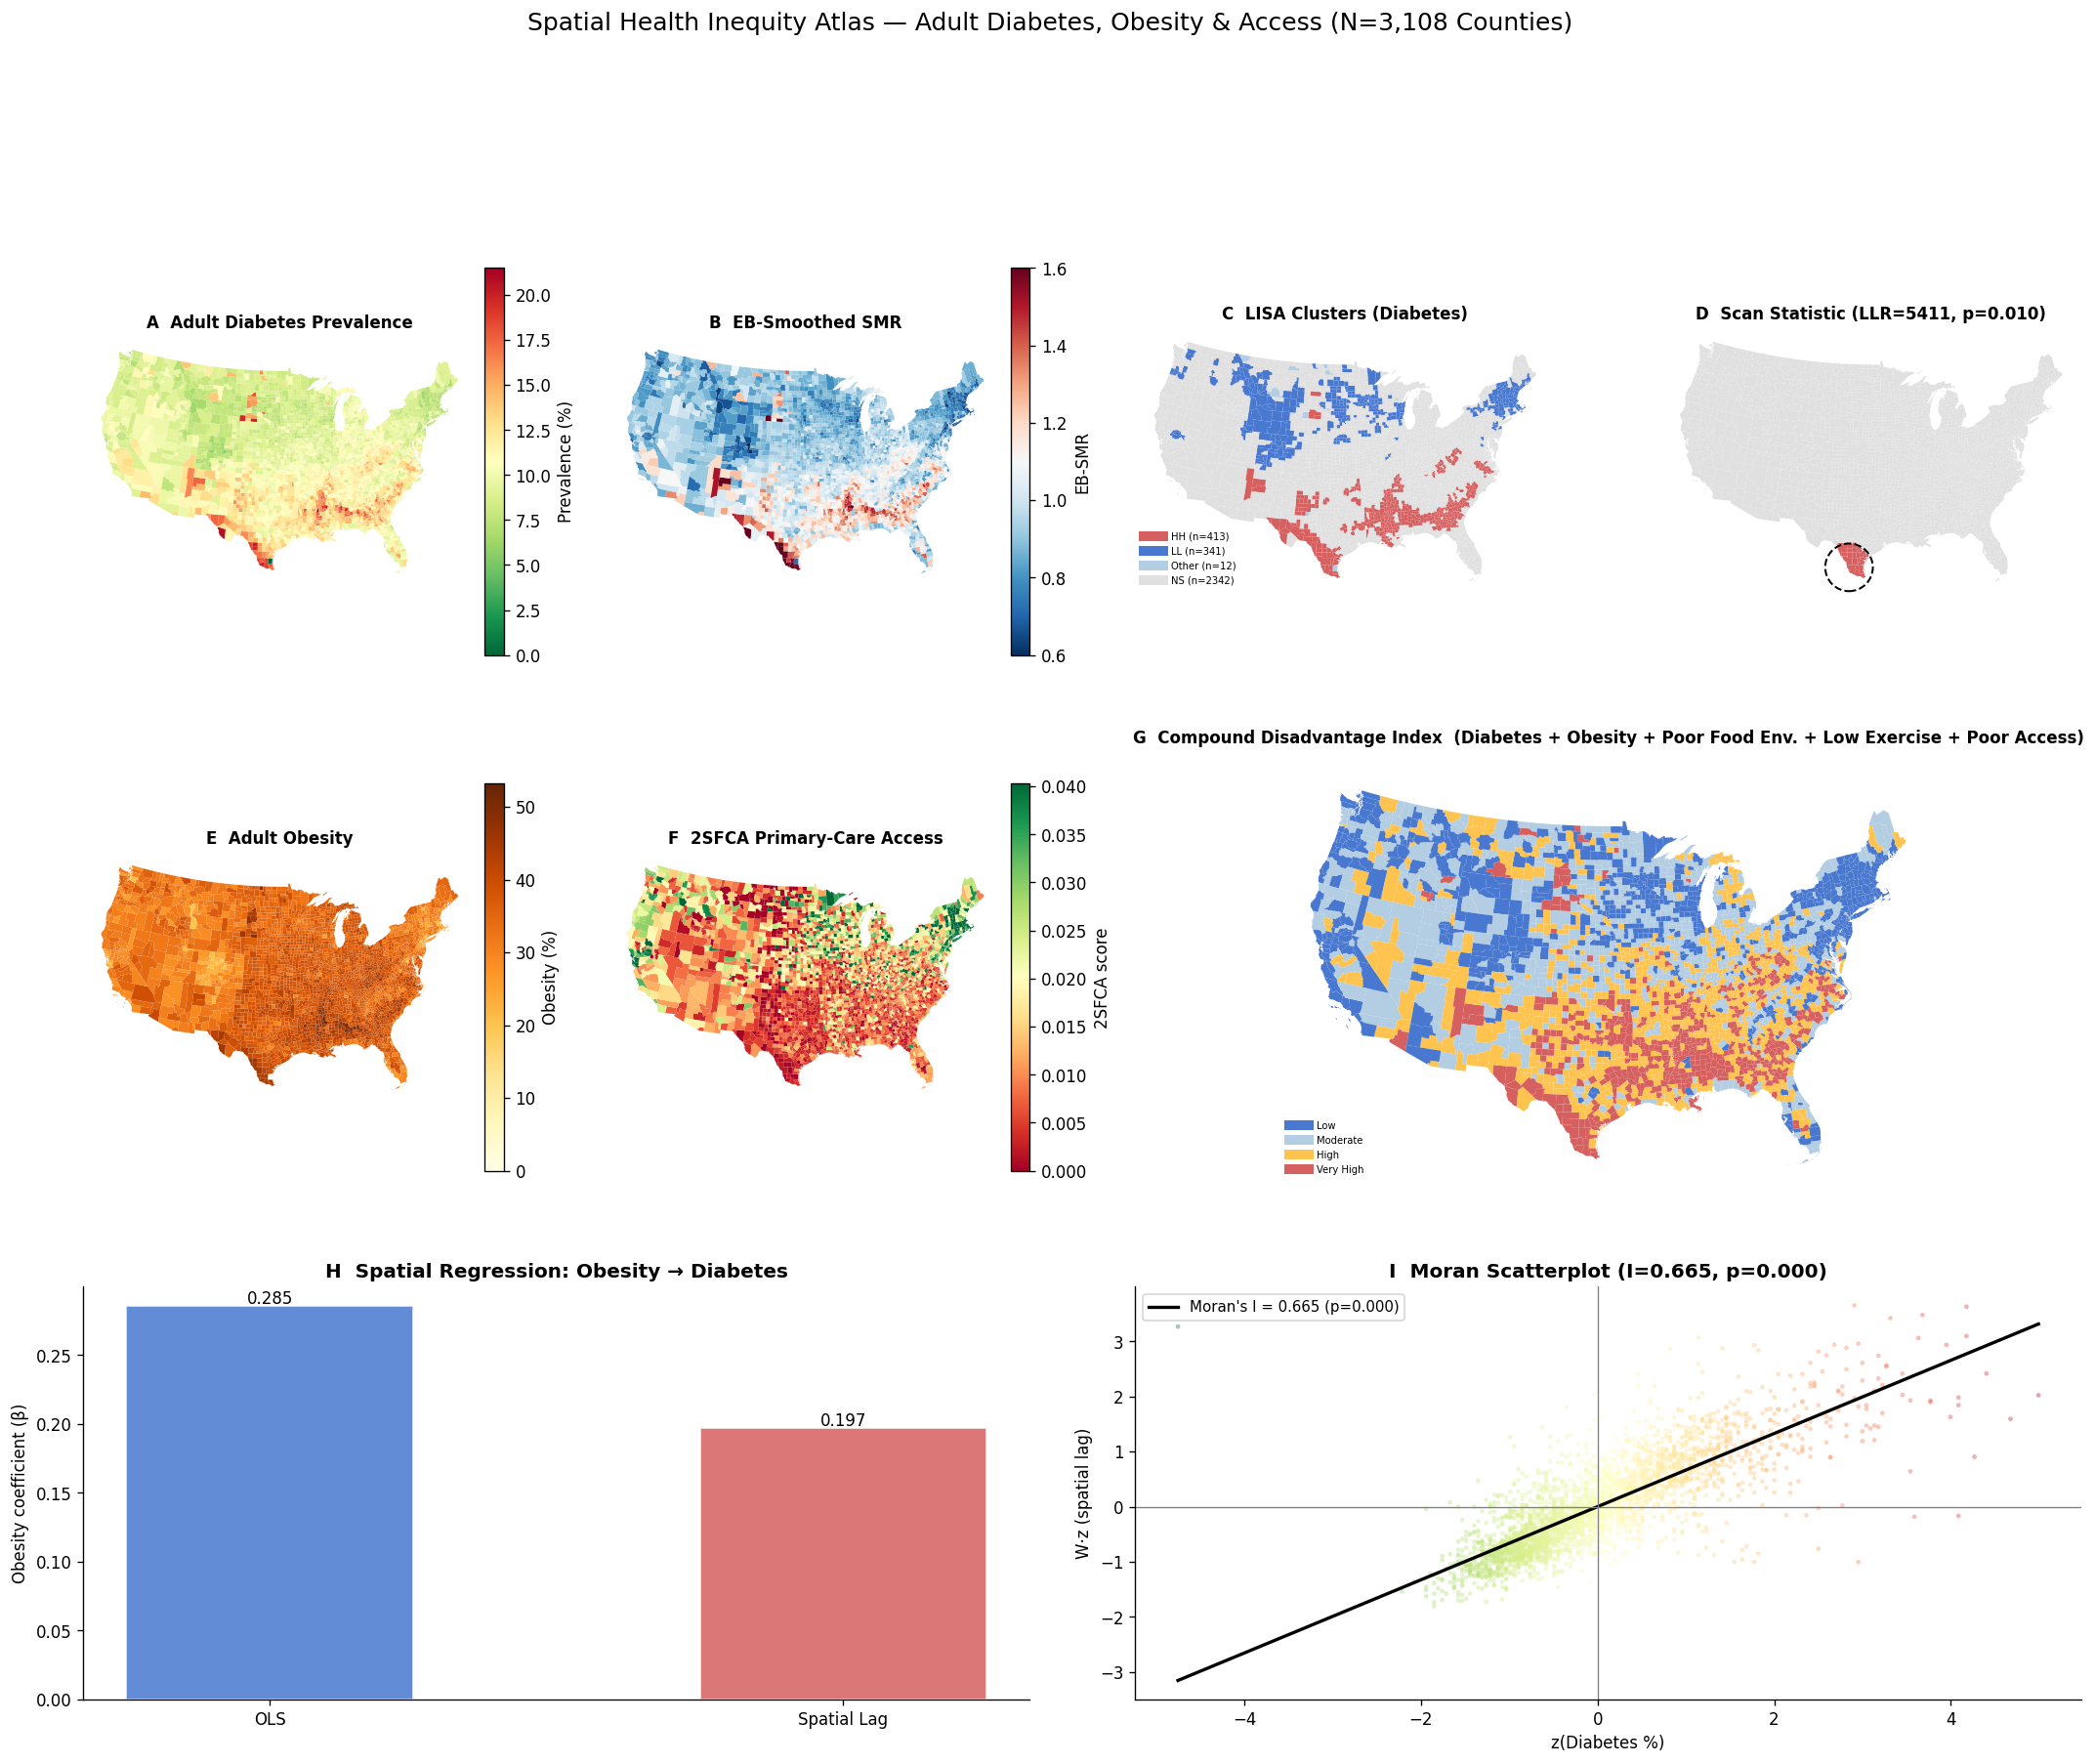

Saved: /tmp/mod07/capstone_spatial_atlas.png (300 dpi)


In [8]:
def choro(ax, column, title, cmap="RdYlGn_r", label="", vmin=None, vmax=None):
    gdf.plot(column=column, cmap=cmap, linewidth=0.04, edgecolor="none",
             ax=ax, legend=False, vmin=vmin, vmax=vmax)
    smap = cm.ScalarMappable(norm=mcolors.Normalize(
        vmin=gdf[column].min() if vmin is None else vmin,
        vmax=gdf[column].max() if vmax is None else vmax), cmap=cmap)
    smap.set_array([])
    fig.colorbar(smap, ax=ax, fraction=0.046, pad=0.02, label=label)
    ax.set_axis_off()
    ax.set_title(title, fontweight="bold", fontsize=10)

def choro_cat(ax, colors, title, legend_items):
    gdf.plot(color=colors, linewidth=0.04, edgecolor="none", ax=ax)
    for lab, col in legend_items.items():
        ax.plot([], [], "-", color=col, lw=6, label=lab)
    ax.legend(fontsize=6, loc="lower left", frameon=False)
    ax.set_axis_off()
    ax.set_title(title, fontweight="bold", fontsize=10)

fig = plt.figure(figsize=(22, 16))
fig.suptitle(f"Spatial Health Inequity Atlas — Adult Diabetes, Obesity & Access (N={N:,} Counties)",
             fontsize=15, y=1.01)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.25, wspace=0.25)

CLUSTER_COLORS = {"HH": "#D65F5F", "LL": "#4878CF", "Other": "#B3CDE3", "NS": "#E0E0E0"}
CDI_COLORS = {"Low": "#4878CF", "Moderate": "#B3CDE3", "High": "#FEC44F", "Very High": "#D65F5F"}

ax_a = fig.add_subplot(gs[0, 0])
choro(ax_a, "Diabetes", "A  Adult Diabetes Prevalence", "RdYlGn_r", "Prevalence (%)")

ax_b = fig.add_subplot(gs[0, 1])
choro(ax_b, "smr_eb", "B  EB-Smoothed SMR", "RdBu_r", "EB-SMR", vmin=0.6, vmax=1.6)

ax_c = fig.add_subplot(gs[0, 2])
lisa_cols = [CLUSTER_COLORS.get(c, "#E0E0E0") for c in gdf.lisa_diabetes]
choro_cat(ax_c, lisa_cols, "C  LISA Clusters (Diabetes)",
          {f"{k} (n={(gdf.lisa_diabetes==k).sum()})": v for k, v in CLUSTER_COLORS.items()})

ax_d = fig.add_subplot(gs[0, 3])
scan_cols = np.where(gdf.in_scan_cluster, "#D65F5F", "#E0E0E0")
gdf.plot(color=scan_cols, linewidth=0.04, edgecolor="none", ax=ax_d)
circle = plt.Circle((cx, cy), best_r, fill=False, edgecolor="black", lw=1.2, ls="--")
ax_d.add_patch(circle)
ax_d.set_axis_off()
ax_d.set_title(f"D  Scan Statistic (LLR={best_llr:.0f}, p={p_scan:.3f})",
               fontweight="bold", fontsize=10)

ax_e = fig.add_subplot(gs[1, 0])
choro(ax_e, "Obesity", "E  Adult Obesity", "YlOrBr", "Obesity (%)")

ax_f = fig.add_subplot(gs[1, 1])
choro(ax_f, "access_2sfca", "F  2SFCA Primary-Care Access", "RdYlGn", "2SFCA score",
      vmin=0, vmax=np.nanpercentile(gdf.access_2sfca, 95))

ax_g = fig.add_subplot(gs[1, 2:])
cdi_cols = [CDI_COLORS.get(str(c), "#E0E0E0") for c in gdf.cdi_cat]
choro_cat(ax_g, cdi_cols,
          "G  Compound Disadvantage Index  (Diabetes + Obesity + Poor Food Env. + Low Exercise + Poor Access)",
          CDI_COLORS)

ax_h = fig.add_subplot(gs[2, :2])
methods_r = ["OLS", "Spatial Lag"]
coefs_r = [ols_ob, slm_ob]
bars_r = ax_h.bar(methods_r, coefs_r, color=["#4878CF", "#D65F5F"],
                  alpha=0.85, edgecolor="white", width=0.5)
ax_h.set_ylabel("Obesity coefficient (β)")
ax_h.set_title("H  Spatial Regression: Obesity → Diabetes", fontweight="bold")
for bar, val in zip(bars_r, coefs_r):
    ax_h.text(bar.get_x() + bar.get_width()/2, val + 0.002, f"{val:.3f}", ha="center", fontsize=10)
ax_h.axhline(0, color="gray", lw=0.6)

ax_i = fig.add_subplot(gs[2, 2:])
z_d = (gdf["Diabetes"] - gdf["Diabetes"].mean()) / gdf["Diabetes"].std()
Wz_d = W @ z_d
ax_i.scatter(z_d, Wz_d, c=gdf["Diabetes"], cmap="RdYlGn_r", alpha=0.35, s=8, edgecolors="none")
m = np.polyfit(z_d, Wz_d, 1)[0]
xl = np.linspace(z_d.min(), z_d.max(), 100)
ax_i.plot(xl, m * xl, "k-", lw=2, label=f"Moran's I = {I_diab:.3f} (p={p_diab:.3f})")
ax_i.axhline(0, color="gray", lw=0.8); ax_i.axvline(0, color="gray", lw=0.8)
ax_i.set_xlabel("z(Diabetes %)"); ax_i.set_ylabel("W·z (spatial lag)")
ax_i.set_title(f"I  Moran Scatterplot (I={I_diab:.3f}, p={p_diab:.3f})", fontweight="bold")
ax_i.legend(fontsize=9)

plt.savefig("/tmp/mod07/capstone_spatial_atlas.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved: /tmp/mod07/capstone_spatial_atlas.png (300 dpi)")


## 8. Methods Narrative Template

> **Spatial Epidemiology Methods**
>
> We conducted a county-level (N=3,108; CONUS + DC) spatial analysis of adult diabetes prevalence, metabolic and food-environment risk factors, and primary-care access. County Health Rankings and CDC diabetes prevalence were joined to NAD83 Albers county polygons (EPSG:5070). Standardised prevalence ratios (SPR) were computed as each county's rate divided by the national mean. Empirical Bayes (Gamma-Poisson) smoothing used the CHR uninsured count as a working at-risk denominator to stabilise SPR estimates in small counties.
>
> Spatial autocorrelation was assessed using Global Moran's I with queen-contiguity weights, evaluated against 499 permutation-based null replicates. Local spatial clusters were identified with LISA (p<0.05), and disease hot spots confirmed with the Kulldorff circular scan statistic (B=99 Monte Carlo permutations, 15% maximum expected-count window).
>
> Diabetes prevalence was regressed on obesity, share aged 65+, access to exercise opportunities, and the food environment index using OLS and a spatial lag model (SLM; concentrated likelihood with eigenvalue log-determinant). Primary-care access was quantified with the Two-Step Floating Catchment Area (2SFCA) method using PCP counts as supply, uninsured counts as need-weighted demand, a 100 km catchment, and distance-decay power of 2.
>
> A Compound Disadvantage Index (CDI) was constructed by averaging quintile scores across diabetes prevalence, obesity, food environment (inverted), exercise access (inverted), and 2SFCA access, identifying counties bearing multiple simultaneous burdens. All analyses used Python 3 (geopandas, libpysal, scipy, statsmodels).


## 9. Final Knowledge Check
1. The scan statistic detects a cluster with p=0.02 but the LISA map shows only a handful of HH counties overlapping that window. How do you reconcile these findings?
2. The SLM obesity coefficient is lower than OLS. Explain conceptually why spatial adjustment can reduce the estimate.
3. CDI identifies a set of counties with "Very High" compound disadvantage. A policy maker wants to intervene in all of them. What information would you add to prioritise among them?
4. EB smoothing reduces SMR variance. What are the implications for mapping and for identifying outlier counties?
5. Design a study using interrupted time-series analysis (from Module 06) to evaluate whether a telemedicine programme in low-2SFCA counties reduced diabetes prevalence over 5 years.


In [9]:
print("CAPSTONE SUMMARY STATISTICS")
print("=" * 60)
print(f"Global Moran's I (Diabetes): {I_diab:.4f} (p={p_diab:.4f})")
print(f"LISA HH clusters: {(gdf.lisa_diabetes=='HH').sum()} | LL: {(gdf.lisa_diabetes=='LL').sum()} counties")
print(f"Scan cluster: LLR={best_llr:.1f} | p={p_scan:.3f} | n={len(best_in)} counties | RR={RR:.2f}")
print(f"OLS obesity β={ols_ob:.3f} | SLM obesity β={slm_ob:.3f} | ρ={rho_best:.3f}")
print(f"EB smoothing: SMR SD {gdf.smr.std():.4f} → {gdf.smr_eb.std():.4f} "
      f"({(1 - gdf.smr_eb.std()/gdf.smr.std())*100:.1f}% variance reduction)")
print(f"Compound Disadvantage Index (Very High): {(gdf.cdi_cat=='Very High').sum()} counties "
      f"({(gdf.cdi_cat=='Very High').mean()*100:.1f}%)")
print("=" * 60)


CAPSTONE SUMMARY STATISTICS
Global Moran's I (Diabetes): 0.6650 (p=0.0000)
LISA HH clusters: 413 | LL: 341 counties
Scan cluster: LLR=5410.5 | p=0.010 | n=32 counties | RR=1.52
OLS obesity β=0.285 | SLM obesity β=0.197 | ρ=0.500
EB smoothing: SMR SD 0.2104 → 0.1604 (23.8% variance reduction)
Compound Disadvantage Index (Very High): 536 counties (17.2%)


***
## Module 07 Complete

**NB-01** Spatial data & choropleth: data types (point/polygon/raster), GeoDataFrame, quintile/Jenks classification, age-standardised rates, SMR computation, bivariate choropleth, hospital spatial join  
**NB-02** Spatial autocorrelation: queen/rook/distance weights matrices, Global Moran's I with permutation inference, Moran scatterplot, LISA (HH/LL/HL/LH), Getis-Ord G* hot spot analysis, Moran's I on OLS residuals  
**NB-03** Spatial regression & GWR: OLS residual diagnostics, LM lag/error tests, spatial lag model (SLM, ML estimation), spatial error model (SEM), GWR from scratch with bandwidth sensitivity, spatially varying coefficient maps  
**NB-04** Disease mapping & Bayesian smoothing: small-area estimation problem, Gamma-Poisson empirical Bayes, BYM/ICAR model structure, Moran eigenvector spatial smoothing, KDE risk surface, PyMC BYM starter code  
**NB-05** Cluster detection: Kulldorff circular scan statistic, Poisson LLR, Monte Carlo permutation inference, cluster performance evaluation (sensitivity/specificity/PPV), LISA vs scan comparison, secondary cluster detection  
**NB-06** Environmental epidemiology: IDW/RBF exposure interpolation, ecological regression, ecological fallacy, environmental justice (quintile and concentration index), individual vs aggregate effect comparison  
**NB-07** Health service access: PPR, nearest-distance, 2SFCA method, HPSA-style shortage area delineation, access-deprivation correlation, concentration index, Gini coefficient for access distribution  
**NB-08** Capstone: full pipeline on 3,108 US counties → EB smoothing → Moran's I → LISA → scan stat → SLM → 2SFCA → CDI → 8-panel 300 dpi atlas → methods narrative

**Next → Module 08: Reproducible Research & Deployment**
